# Домашнє завдання: Прогнозування кредитного ризику

## Мета завдання
Застосувати знання з лекції для побудови моделі логістичної регресії, що прогнозує ймовірність дефолту за кредитом, іншими словами, що людина не поверне кредит. Ви пройдете весь цикл: від дослідницького аналізу до оцінки якості класифікаційної моделі.

## Опис датасету
**Credit Risk Dataset** містить інформацію про 32,000+ позичальників з такими параметрами:
- **person_age**: Вік позичальника
- **person_income**: Річний дохід
- **person_home_ownership**: Тип володіння житлом
- **person_emp_length**: Стаж роботи (в роках)
- **loan_intent**: Мета кредиту
- **loan_grade**: Кредитний рейтинг (A - кращий, F - гірший)
- **loan_amnt**: Сума кредиту
- **loan_int_rate**: Процентна ставка
- **loan_status**: Статус кредиту (0 = сплачено, 1 = дефолт) - **цільова змінна**
- **loan_percent_income**: Відношення кредиту до доходу
- **cb_person_default_on_file**: Історія дефолтів (Y/N)
- **cb_person_cred_hist_length**: Довжина кредитної історії

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `credit_risk_dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (кількість записів, типи колонок)
5. Перевірте розподіл цільової змінної (відсотк даних для кожного класу)

Дайте висновок, це задача збалансованої чи незбалансованої класифікації.


In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

pd.set_option('display.max_columns', None)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


1. Завантажте дані з файлу credit_risk_dataset.csv
2. Виведіть розмір датасету

In [4]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datasets/credit_risk_dataset.csv')

print(f"Розмір датасету: {df.shape}")
print(f"Кількість клієнтів: {df.shape[0]:,}")
print(f"Кількість ознак: {df.shape[1]}")



Розмір датасету: (32581, 12)
Кількість клієнтів: 32,581
Кількість ознак: 12


3. Покажіть перші 5 рядків

In [5]:
df.head(5)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


4. Виведіть загальну інформацію про дані (кількість записів, типи колонок)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


5. Перевірте розподіл цільової змінної (відсотк даних для кожного класу)

In [7]:
print(df['loan_status'].value_counts())

print(df['loan_status'].value_counts(normalize=True) * 100)

loan_status
0    25473
1     7108
Name: count, dtype: int64
loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64


Датасет є незбалансованим, оскільки клас 0 (виплачено) становить 78%, а клас 1 (дефолт) 22%. Один клас суттєво переважає інший.


---

## Завдання 2: Дослідницький аналіз даних (EDA) (4 бали)

**Що потрібно зробити:**
1. Обчисліть відсоток пропущених значень в колонках. За наявності пропущених значень - заповніть їх медіаною для числових колонок і найбільш частим значеннмя для категоріальних.
2. Проаналізуйте розподіл числових змінних.
3. Знайдіть та обробіть викиди в колонці person_income з допомогою [Interquartile range](https://uk.wikipedia.org/wiki/%D0%9C%D1%96%D0%B6%D0%BA%D0%B2%D0%B0%D1%80%D1%82%D0%B8%D0%BB%D1%8C%D0%BD%D0%B8%D0%B9_%D1%80%D0%BE%D0%B7%D0%BC%D0%B0%D1%85).
4. Проаналізуйте категоріальні змінні відносно цільової та частоту зустрічання різних значень в них.
5. Візуалізуйте взаємозв'язок ознак з цільовою змінною.


1. Обчисліть відсоток пропущених значень в колонках. За наявності пропущених значень - заповніть їх медіаною для числових колонок і найбільш частим значеннмя для категоріальних.

In [9]:
missing_percent = df.isnull().mean() * 100
missing_percent[missing_percent > 0]

,0
person_emp_length,2.747000
loan_int_rate,9.563856


In [10]:
# числові колонки
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# категоріальні колонки
categorical_cols = df.select_dtypes(include=['object']).columns

# заповнення числових медіаною
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# заповнення категоріальних найчастішим значенням
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# перевірка
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,0
loan_status,0
loan_percent_income,0


2. Проаналізуйте розподіл числових змінних.

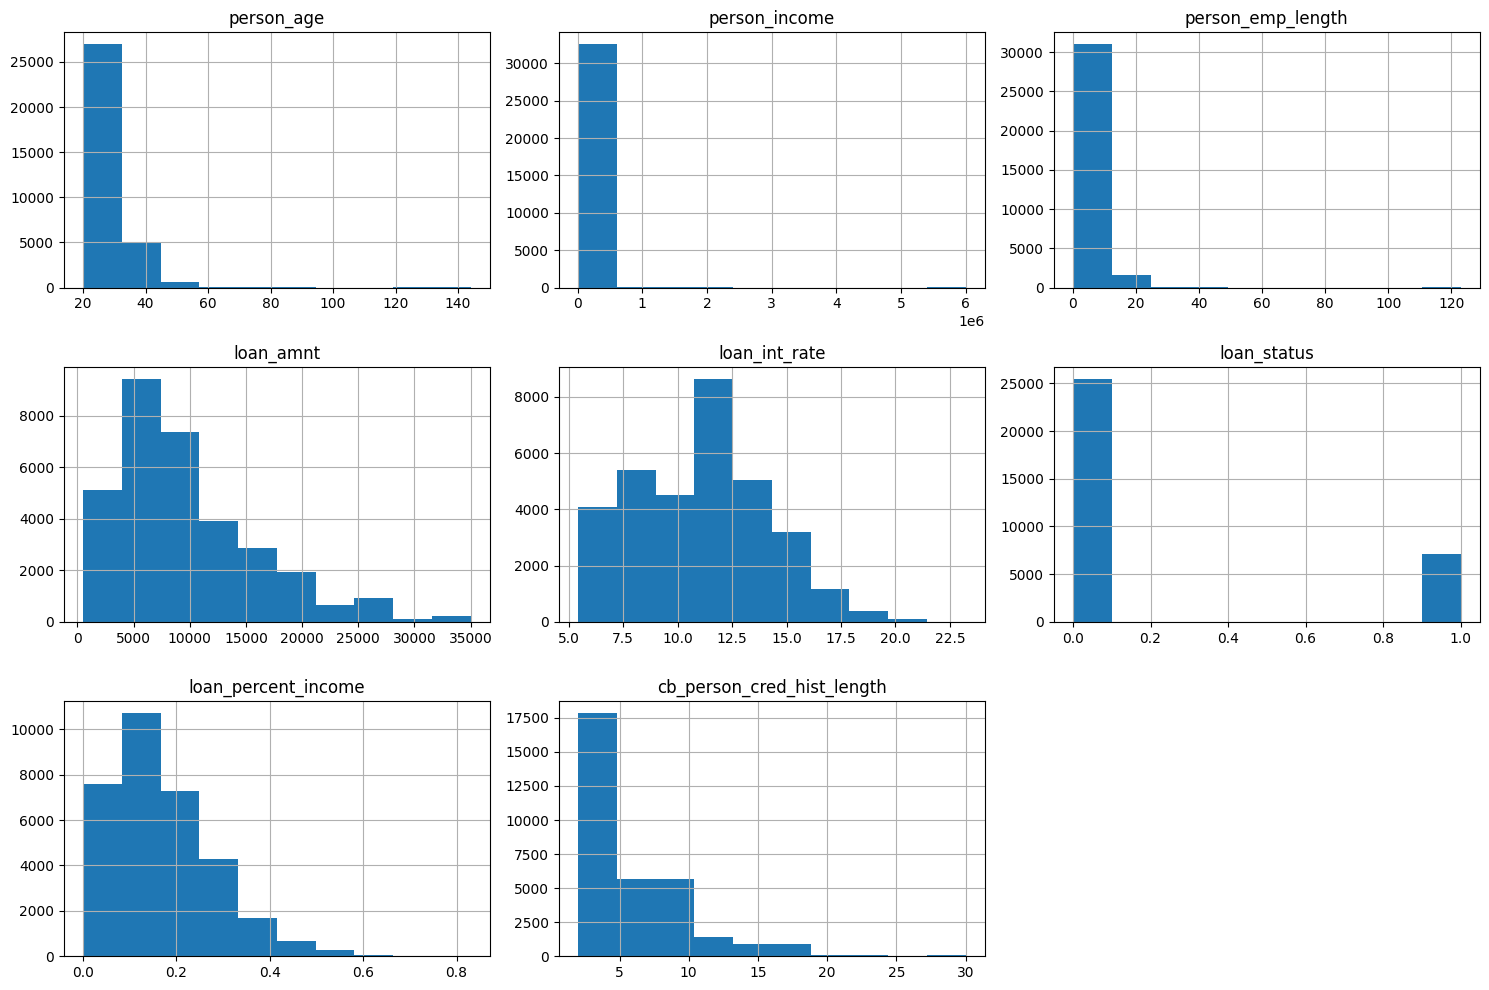

In [12]:
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[numeric_cols].hist(figsize=(15,10))
plt.tight_layout()
plt.show()

Більшість змінних мають правосторонню асиметрію (довгий хвіст вправо), зокрема person_income, loan_amnt, person_emp_length та cb_person_cred_hist_length, що свідчить про наявність великих значень і можливих викидів.

Змінна person_age має концентрацію значень у діапазоні 20–40 років, що відповідає типовому віку позичальників.
Змінна loan_int_rate має відносно більш рівномірний розподіл, але також із незначною асиметрією.

Змінна loan_percent_income показує, що більшість позичальників витрачає невелику частину доходу на кредит, однак присутні випадки з високим навантаженням.

3. Знайдіть та обробіть викиди в колонці person_income з допомогою Interquartile range.

In [13]:
Q1 = df['person_income'].quantile(0.25)
Q3 = df['person_income'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound, upper_bound)

-22550.0 140250.0


In [14]:
outliers = df[(df['person_income'] < lower_bound) | (df['person_income'] > upper_bound)]
print(f"Кількість викидів: {len(outliers)}")

Кількість викидів: 1484


In [17]:
df['person_income'] = df['person_income'].clip(lower_bound, upper_bound)

Було виявлено викиди у змінній person_income за допомогою методу міжквартильного розмаху (IQR).
Кількість викидів становить 1484 спостереження (4.5% від усіх даних).

Для їх обробки було використано метод обмеження значень (clipping), при якому всі значення, що виходять за межі [Q1 - 1.5*IQR; Q3 + 1.5*IQR], були приведені до граничних значень.
Такий підхід дозволяє зберегти всі спостереження без втрати даних.

4. Проаналізуйте категоріальні змінні відносно цільової та частоту зустрічання різних значень в них.

In [18]:
categorical_cols = df.select_dtypes(include=['object']).columns
print(categorical_cols)

Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object')


In [19]:
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


person_home_ownership
person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64

loan_intent
loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

loan_grade
loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64

cb_person_default_on_file
cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64


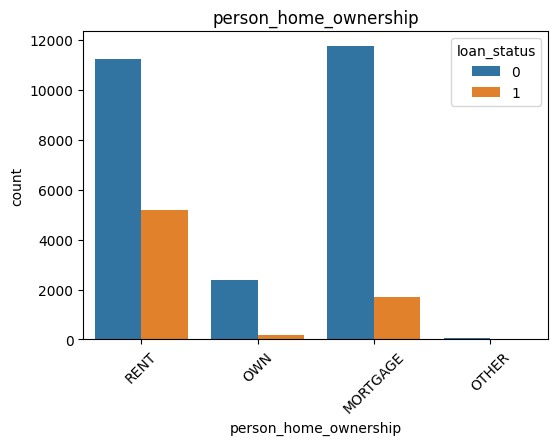

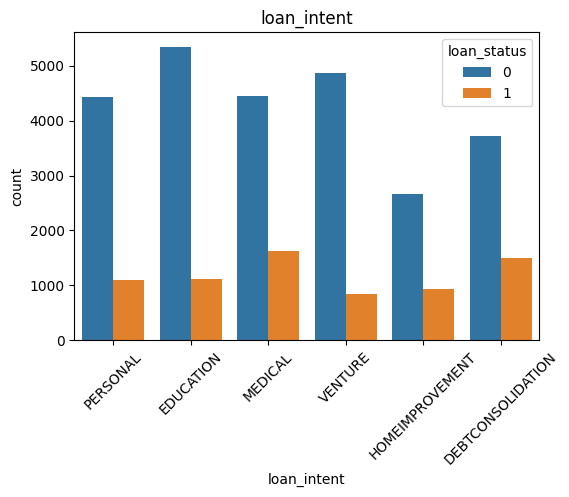

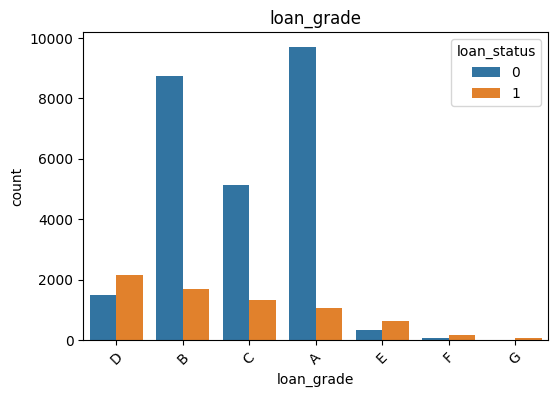

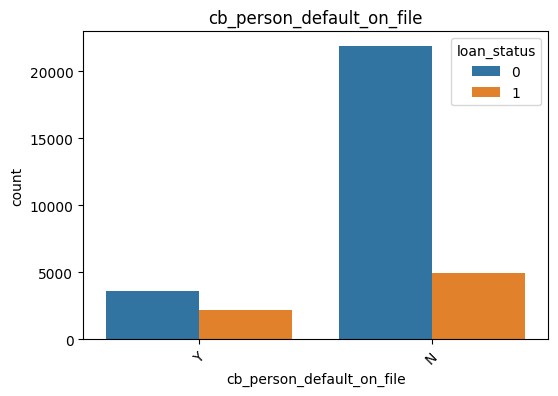

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='loan_status', data=df)
    plt.title(col)
    plt.xticks(rotation=45)
    plt.show()

Змінна person_home_ownership показує, що користувачі з житлом у власності (OWN) мають нижчу частку дефолтів порівняно з RENT, де ризик вищий.

Змінна loan_intent демонструє, що найбільша частка дефолтів спостерігається для категорій MEDICAL та DEBTCONSOLIDATION, що може свідчити про фінансові труднощі позичальників.

Кредитний рейтинг (loan_grade) має сильний вплив на дефолт: зі зниженням рейтингу (від A до G) частка дефолтів значно зростає, що є логічним та очікуваним результатом.

Змінна cb_person_default_on_file показує, що наявність попередніх дефолтів (Y) значно підвищує ймовірність нового дефолту.

Отже, категоріальні змінні мають суттєвий вплив на цільову змінну і є важливими предикторами для побудови моделі.

5. Візуалізуйте взаємозв'язок ознак з цільовою змінною.

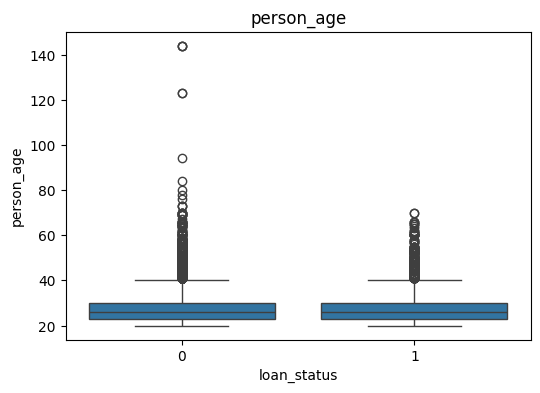

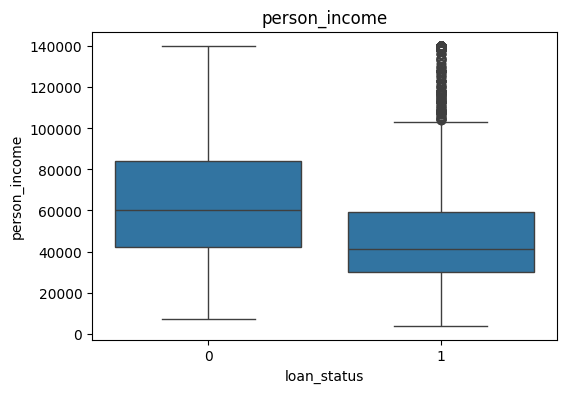

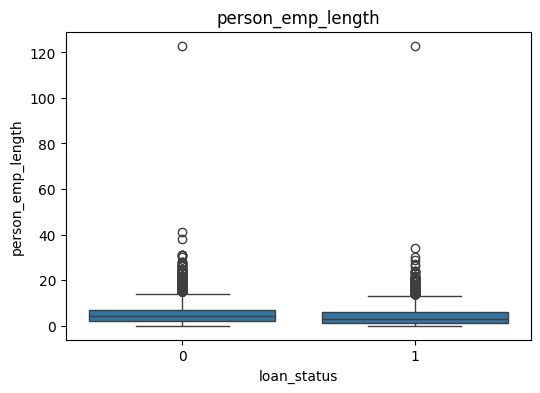

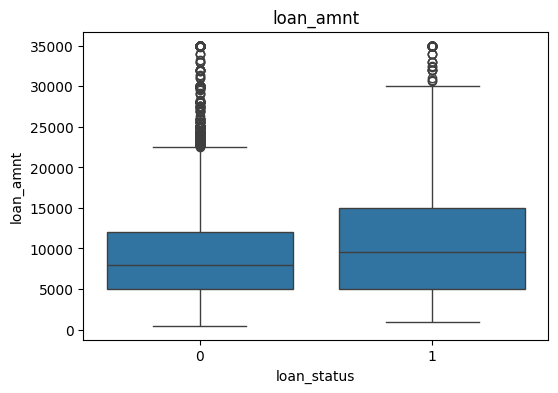

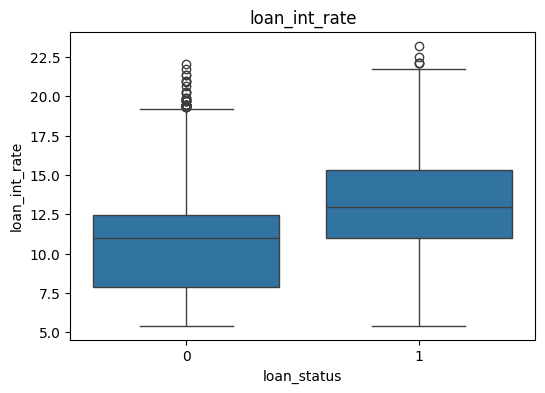

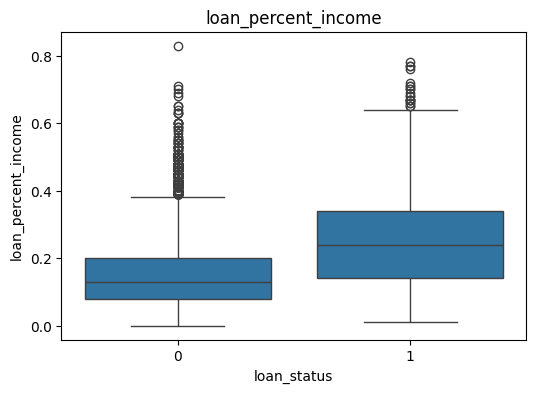

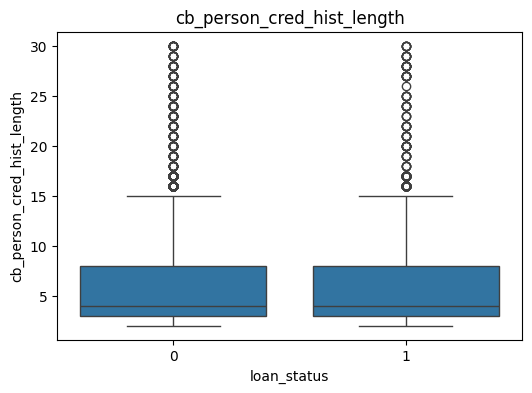

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    if col != 'loan_status':
        plt.figure(figsize=(6,4))
        sns.boxplot(x='loan_status', y=col, data=df)
        plt.title(col)
        plt.show()

Було візуалізовано взаємозв’язок між числовими ознаками та цільовою змінною loan_status.

Аналіз показав, що позичальники з дефолтом (loan_status = 1) мають, як правило, нижчий дохід (person_income) порівняно з тими, хто успішно погасив кредит.
Також для них характерні вищі значення процентної ставки (loan_int_rate) та більшого кредитного навантаження (loan_percent_income).

Змінна loan_amnt показує, що суми кредиту в середньому вищі у групі з дефолтом.
Водночас змінні person_age та cb_person_cred_hist_length не демонструють суттєвої різниці між класами.

Отже, найбільш інформативними числовими ознаками виглядають person_income, loan_int_rate та loan_percent_income, які можуть суттєво впливати на ймовірність дефолту.


---

## Завдання 3: Аналіз кореляцій та Feature Engineering (3 бали)

**Що потрібно зробити:**
1. Побудуйте матрицю кореляцій для числових змінних.
2. Закодуйте категоріальні змінні.
3. Виберіть фінальний набір ознак, можна лишити всі, якщо ви вважаєте, що це - доцільно.



1. Побудуйте матрицю кореляцій для числових змінних.

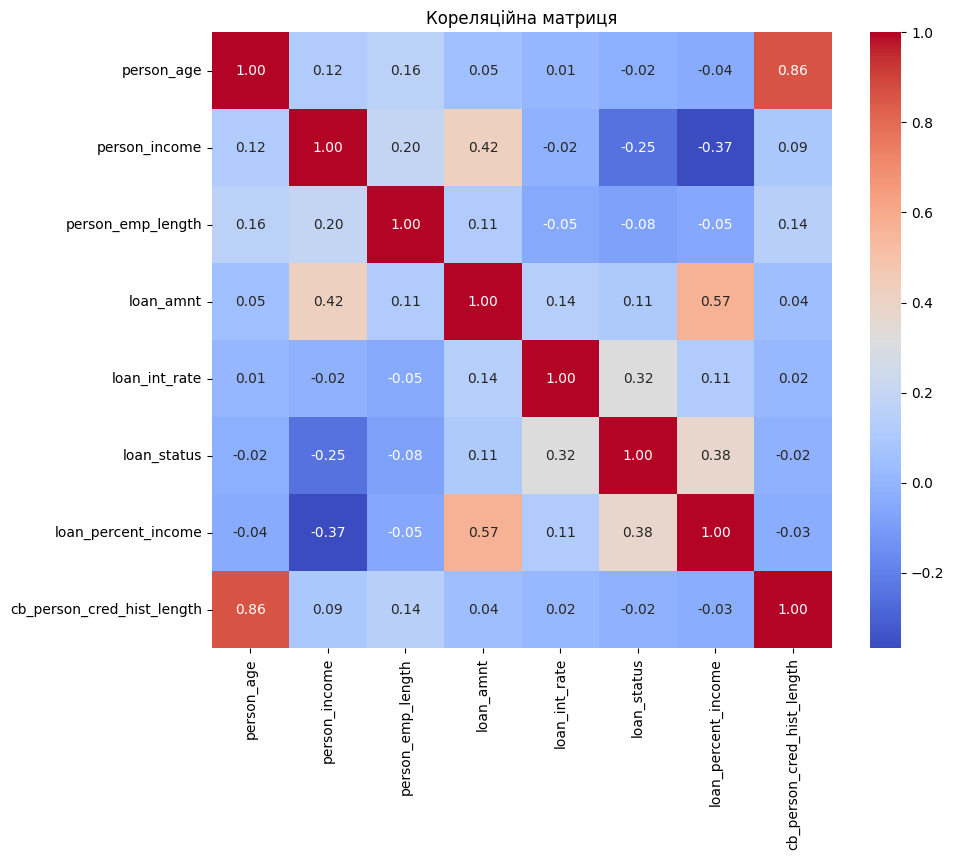

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# тільки числові змінні
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# кореляційна матриця
corr_matrix = numeric_df.corr()

# heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Кореляційна матриця")
plt.show()

Найбільший зв’язок із цільовою змінною loan_status мають ознаки loan_percent_income (0.38) та loan_int_rate (≈0.32), що свідчить про те, що більший кредитний тиск та вищі відсоткові ставки підвищують ймовірність дефолту.

Змінна person_income має помірно негативну кореляцію з цільовою змінною (-0.25), що означає: чим вищий дохід, тим менший ризик дефолту.

Також спостерігається сильна кореляція між person_age та cb_person_cred_hist_length (0.86), що є логічним, оскільки з віком зростає кредитна історія.

Сильних кореляцій між більшістю ознак не виявлено, що свідчить про відсутність серйозної мультиколінеарності.

2. Закодуйте категоріальні змінні.

In [24]:
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,123.0,35000,16.02,1,0.59,3,False,False,True,False,False,False,True,False,False,False,True,False,False,False,True
1,21,9600,5.0,1000,11.14,0,0.10,2,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,0.57,3,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,1,0.53,2,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,1,0.55,4,False,False,True,False,False,True,False,False,False,True,False,False,False,False,True


3. Виберіть фінальний набір ознак, можна лишити всі, якщо ви вважаєте, що це - доцільно.

Видалення ознак не проводилось, оскільки вони можуть містити корисну інформацію для моделі.


---

## Завдання 4: Підготовка даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на X та y
2. Поділіть на навчальну та тестову вибірки
3. Застосуйте масштабування
4. Навчіть модель логістичної регресії
5. Зробіть прогнози на тренувальній та тестовій вибірках.



1. Розділіть дані на X та y

In [25]:
X = df_encoded.drop('loan_status', axis=1)
y = df_encoded['loan_status']

print(X.shape, y.shape)

(32581, 22) (32581,)


2. Поділіть на навчальну та тестову вибірки

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(26064, 22) (6517, 22)


3. Застосуйте масштабування

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

4. Навчіть модель логістичної регресії

In [28]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

5. Зробіть прогнози на тренувальній та тестовій вибірках.

In [29]:
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

y_test_proba = model.predict_proba(X_test_scaled)[:, 1]

Було отримано прогнози для навчальної та тестової вибірок за допомогою моделі логістичної регресії.
Модель передбачає як класи (0 або 1), так і ймовірність належності до класу дефолту.

Ймовірності можуть бути використані для більш гнучкого аналізу ризику.


---

## Завдання 5: Оцінка якості моделі (4 бали)

**Що потрібно зробити:**
1. Побудуйте confusion matrix.
2. Обчисліть основні метрики (accuracy, precision, recall, f1).
3. Побудуйте ROC-криву та обчисліть AUC
4. Проаналізуйте важливість ознак.
5. Зробіть висновки про якість моделі та які ознаки найбільше впливають на прогноз.


1. Побудуйте confusion matrix.

In [30]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)
print(cm)

[[4829  243]
 [ 656  789]]


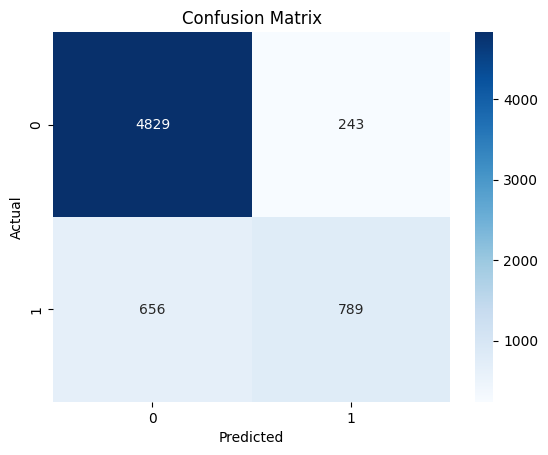

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

Confusion matrix показує, що модель добре визначає клас 0 (відсутність дефолту),
але гірше виявляє клас 1 (дефолт).

Кількість false negatives (656) є відносно високою, що означає,
що модель пропускає частину ризикованих клієнтів.

У задачах кредитування це критично, оскільки такі помилки можуть призвести до фінансових втрат.

2. Обчисліть основні метрики (accuracy, precision, recall, f1).

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1-score:", f1_score(y_test, y_test_pred))

Accuracy: 0.8620530919134571
Precision: 0.7645348837209303
Recall: 0.5460207612456748
F1-score: 0.6370609608397255


3. Побудуйте ROC-криву та обчисліть AUC

AUC: 0.8689821586456071


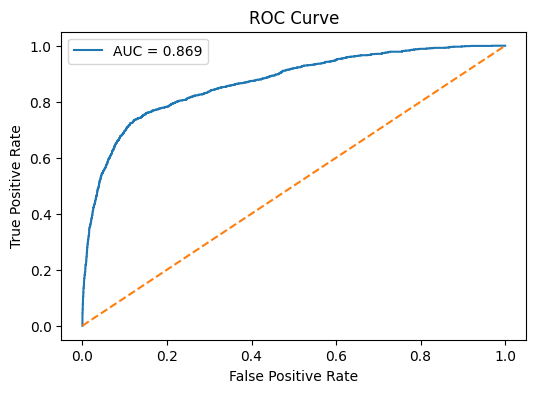

In [33]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

#ROC
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)

#AUC
auc = roc_auc_score(y_test, y_test_proba)
print("AUC:", auc)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')  # линия случайной модели
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

4. Проаналізуйте важливість ознак

In [34]:
import pandas as pd

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.coef_[0]
})

feature_importance['abs_importance'] = feature_importance['importance'].abs()
feature_importance = feature_importance.sort_values(by='abs_importance', ascending=False)

feature_importance.head(10)

,feature,importance,abs_importance
5,loan_percent_income,1.331351,1.331351
17,loan_grade_D,0.833501,0.833501
3,loan_amnt,-0.556813,0.556813
18,loan_grade_E,0.477453,0.477453
8,person_home_ownership_OWN,-0.437722,0.437722
14,loan_intent_VENTURE,-0.428373,0.428373
9,person_home_ownership_RENT,0.425500,0.425500
10,loan_intent_EDUCATION,-0.333843,0.333843
20,loan_grade_G,0.302461,0.302461
19,loan_grade_F,0.289958,0.289958


5. Зробіть висновки про якість моделі та які ознаки найбільше впливають на прогноз.

Модель логістичної регресії продемонструвала хорошу якість.

Значення ROC-AUC ≈ 0.87 свідчить про те, що модель добре розрізняє класи
та має високу здатність відокремлювати надійних клієнтів від ризикових.

Accuracy = 0.86 підтверджує, що більшість прогнозів є правильними.
Precision = 0.76 показує, що модель досить точно визначає дефолти.

Однак recall = 0.55 є відносно низьким, що означає,
що модель пропускає значну частину клієнтів, які можуть не повернути кредит.
Це є важливим недоліком у задачах кредитного скорингу.

Аналіз важливості ознак показав, що найбільший вплив на прогноз мають:

- loan_percent_income (найважливіша ознака)
- loan_grade (особливо категорії D, E, F, G)
- loan_amnt
- тип житла (OWN, RENT)
- мета кредиту (VENTURE, EDUCATION)

Це означає, що ключовими факторами ризику є:
співвідношення кредиту до доходу, кредитний рейтинг, розмір кредиту
та фінансова стабільність позичальника.

Загалом модель є якісною, але її можна покращити,
зокрема шляхом підвищення recall (наприклад, зміною порогу класифікації або балансуванням класів).


---

## Завдання 6: Оптимізація порогу та бізнес-аналіз (2 бали)

**Що потрібно зробити:**
1. Проаналізуйте метрики precision, recall, F1 при різних порогах класифікації (мінімум - 5 різних порогів). Візуалізуйте як змінюються метрики якості при зміні порогу.
2. Оберіть оптимальний поріг для бізнес-задачі - можна обрати виходячи з попереднього пункту, або додати своїх роздумів і обрати інший.



1. Проаналізуйте метрики precision, recall, F1 при різних порогах класифікації (мінімум - 5 різних порогів). Візуалізуйте як змінюються метрики якості при зміні порогу.

In [35]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.2, 0.3, 0.4, 0.5, 0.6]

results = []

for t in thresholds:
    y_pred_thresh = (y_test_proba >= t).astype(int)

    precision = precision_score(y_test, y_pred_thresh)
    recall = recall_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)

    results.append([t, precision, recall, f1])

df_thresholds = pd.DataFrame(results, columns=['threshold', 'precision', 'recall', 'f1'])
df_thresholds

,threshold,precision,recall,f1
0,0.2,0.521619,0.784775,0.626692
1,0.3,0.633514,0.727336,0.677191
2,0.4,0.706154,0.635294,0.668852
3,0.5,0.764535,0.546021,0.637061
4,0.6,0.806533,0.444291,0.572959


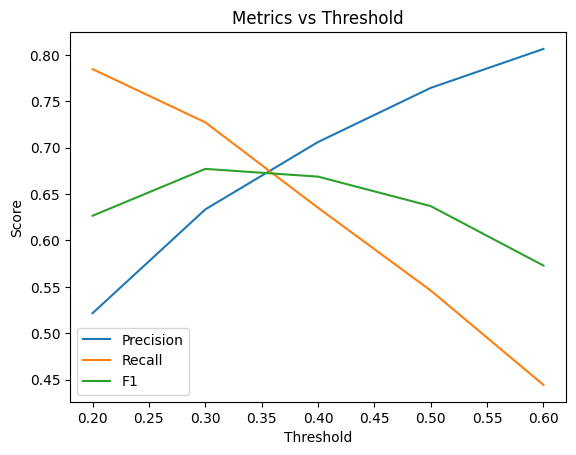

In [36]:
import matplotlib.pyplot as plt

plt.plot(df_thresholds['threshold'], df_thresholds['precision'], label='Precision')
plt.plot(df_thresholds['threshold'], df_thresholds['recall'], label='Recall')
plt.plot(df_thresholds['threshold'], df_thresholds['f1'], label='F1')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Metrics vs Threshold')
plt.legend()
plt.show()

Аналіз метрик при різних порогах показав, що при порозі 0.3 досягається
найкращий баланс між precision та recall (максимальний F1-score 0.677).

З урахуванням бізнес-задачі (мінімізація кредитних ризиків),
обрано поріг 0.3, оскільки він дозволяє краще виявляти потенційні дефолти.

2. Оберіть оптимальний поріг для бізнес-задачі - можна обрати виходячи з попереднього пункту, або додати своїх роздумів і обрати інший.

Оптимальним порогом класифікації обрано значення 0.3.

У задачі кредитного скорингу більш критичною є помилка типу FN
(пропущений дефолт), ніж FP (відмова надійному клієнту).

Тому доцільно обрати поріг 0.3, який забезпечує достатньо високий recall
і дозволяє краще виявляти потенційно ризикових клієнтів.


---

## Завдання 7 (Опціональне): Покращення моделі та висновки (2 бали)

**Що потрібно зробити:**

На цих же даних навчіть DecisionTreeClassifier та RandomForestClassifier. Яка з трьох моделей дає найкращий результат на тестовому наборі?

Поріг класифікації можна для порівняння якостей моделей використовувати стандартний 0.5, або той, що ви виявили, як оптимальний на попередньому кроці.


1. Навчання моделі

In [37]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

2. Передбачення з порогом 0.3

In [39]:
dt_proba = dt_model.predict_proba(X_test_scaled)[:, 1]
rf_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

threshold = 0.3

dt_pred = (dt_proba >= threshold).astype(int)
rf_pred = (rf_proba >= threshold).astype(int)

3. F1

In [40]:
print("Logistic Regression F1:", f1_score(y_test, (y_test_proba >= threshold).astype(int)))
print("Decision Tree F1:", f1_score(y_test, dt_pred))
print("Random Forest F1:", f1_score(y_test, rf_pred))

Logistic Regression F1: 0.6771907216494846
Decision Tree F1: 0.7464788732394366
Random Forest F1: 0.7991528415107659


Висновок:

Було навчено три моделі: Logistic Regression, Decision Tree та Random Forest.

Результати (F1-score):
- Logistic Regression: 0.677
- Decision Tree: 0.746
- Random Forest: 0.799

Найкращий результат показала модель Random Forest.

Для задачі кредитного скорингу доцільно використовувати Random Forest,
оскільки ця модель забезпечує найкращу якість прогнозу та краще
виявляє потенційно ризикових клієнтів.